In [643]:
import numpy as np 
import pandas as pd  
import seaborn as sns
import matplotlib.pyplot as plt 

In [644]:
df = pd.read_csv("nstu_hall_data.csv")

In [645]:
df

,timestamp,name,gender,age_group,dept,year,accom_type,hall_apply,hall_status,room_share,...,sleep_hours,isolated,acad_pressure,study_env,extra_act,internet,fin_stress,cost_affect,safety,safety_impact
0,2026/04/24 12:48:05 pm GMT+6,NaN,Female,23-25,Software engineering,3rd Year,Rented Mess/Flat,No,No,1,...,7,Maybe,Yes,Yes,2.0,4,2,No,1,4
1,2026/04/24 1:15:23 pm GMT+6,NaN,Female,23-25,IIT,3rd Year,Rented Mess/Flat,Yes,No,2,...,6–7,Maybe,Yes,No,2.0,2,4,Yes,3,4
2,2026/04/24 1:17:32 pm GMT+6,NaN,Female,23-25,MIS,4th Year,Rented Mess/Flat,No,No,1,...,6–7,No,Yes,No,2.0,3,5,Yes,3,4
3,2026/04/24 1:27:18 pm GMT+6,NaN,Female,23-25,IIT,3rd Year,Rented Mess/Flat,No,No,1,...,5–6,Maybe,No,Yes,1.0,4,3,Yes,1,5
4,2026/04/24 1:32:31 pm GMT+6,NaN,Male,23-25,Software Engineering,3rd Year,University Hall,Yes,Yes,more than 4,...,5–6,Yes,Yes,Yes,1.0,4,4,No,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,2026/05/06 1:02:09 pm GMT+6,Ayoraf Hossain,Male,23-25,IIT,3rd Year,Rented Mess/Flat,Yes,No,2,...,6–7,Maybe,No,Yes,1.0,3,3,Yes,4,3
112,2026/05/06 6:33:06 pm GMT+6,Prattoy Das,Male,20-22,Software Engineering,2nd Year,Rented Mess/Flat,Yes,No,2,...,6–7,No,No,Yes,1.0,4,3,No,5,1
113,2026/05/06 9:04:56 pm GMT+6,Jaba Rani acharjee,Female,23-25,IIT,3rd Year,University Hall,Yes,Yes,4,...,7-10,Yes,No,No,1.0,2,3,Yes,2,3
114,2026/05/07 10:36:08 am GMT+6,Orpa,Female,23-25,IIT,3rd Year,Rented Mess/Flat,Yes,No,1,...,5–6,Maybe,Yes,No,2.0,2,1,Yes,3,3


In [646]:
df.drop(['timestamp','name'], axis=1, inplace=True)

In [647]:
df

,gender,age_group,dept,year,accom_type,hall_apply,hall_status,room_share,living_sat,distance,...,sleep_hours,isolated,acad_pressure,study_env,extra_act,internet,fin_stress,cost_affect,safety,safety_impact
0,Female,23-25,Software engineering,3rd Year,Rented Mess/Flat,No,No,1,2,3–5 km,...,7,Maybe,Yes,Yes,2.0,4,2,No,1,4
1,Female,23-25,IIT,3rd Year,Rented Mess/Flat,Yes,No,2,4,5 km,...,6–7,Maybe,Yes,No,2.0,2,4,Yes,3,4
2,Female,23-25,MIS,4th Year,Rented Mess/Flat,No,No,1,2,3–5 km,...,6–7,No,Yes,No,2.0,3,5,Yes,3,4
3,Female,23-25,IIT,3rd Year,Rented Mess/Flat,No,No,1,1,3–5 km,...,5–6,Maybe,No,Yes,1.0,4,3,Yes,1,5
4,Male,23-25,Software Engineering,3rd Year,University Hall,Yes,Yes,more than 4,4,On campus,...,5–6,Yes,Yes,Yes,1.0,4,4,No,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,Male,23-25,IIT,3rd Year,Rented Mess/Flat,Yes,No,2,5,<1 km,...,6–7,Maybe,No,Yes,1.0,3,3,Yes,4,3
112,Male,20-22,Software Engineering,2nd Year,Rented Mess/Flat,Yes,No,2,5,>5 km,...,6–7,No,No,Yes,1.0,4,3,No,5,1
113,Female,23-25,IIT,3rd Year,University Hall,Yes,Yes,4,2,On campus,...,7-10,Yes,No,No,1.0,2,3,Yes,2,3
114,Female,23-25,IIT,3rd Year,Rented Mess/Flat,Yes,No,1,4,1–3 km,...,5–6,Maybe,Yes,No,2.0,2,1,Yes,3,3


In [648]:
df.isnull().sum()

gender            0
age_group         0
dept              0
year              0
accom_type        0
hall_apply        0
hall_status       0
room_share        6
living_sat        0
distance          0
commute_oneway    0
commute_total     0
transport         1
transport_cost    0
late_commute      0
living_cost       0
cgpa              0
study_hours       0
attendance        0
miss_class        0
study_diff        0
grade_drop        0
stress            0
anxiety           0
sleep_hours       0
isolated          2
acad_pressure     0
study_env         0
extra_act         1
internet          0
fin_stress        0
cost_affect       1
safety            0
safety_impact     0
dtype: int64

In [649]:
df.duplicated().sum()

np.int64(0)

Standardize texts & Inconsistent departments

In [650]:
df["dept"] = df["dept"].str.strip().str.lower()

In [651]:
df["dept"] = df["dept"].replace({

    # Software Engineering
    "software engineering": "Software Engineering",
    "software engineering ": "Software Engineering",
    "software engineering (iit)": "Software Engineering",
    "software engineerin": "Software Engineering",
    "se": "Software Engineering",

    # IIT
    "iit": "IIT",
    "iit ": "IIT",
    "iit(se)": "IIT",
    "iit (se)": "IIT",

    # MIS
    "mis": "MIS",
    "mis ": "MIS",

    # Statistics
    "statistics": "Statistics",
    "statistics ": "Statistics",

    # BMB
    "bmb": "Biochemistry and Molecular Biology",
    "biochemistry and molecular biology": "Biochemistry and Molecular Biology",
    "biochemistry & molecular biology": "Biochemistry and Molecular Biology",

    # BGE
    "bge": "Biotechnology and Genetic Engineering",
    "biotechnology and genetic engineering": "Biotechnology and Genetic Engineering",

    # Applied Mathematics
    "applied mathematics": "Applied Mathematics",
    "applied math": "Applied Mathematics",

    # IICT
    "iict": "IICT",

    # SWES
    "swes": "SWES",

    # EEE
    "eee": "EEE",

    # DBA
    "dba": "DBA",

    # CSE
    "cse": "CSE",

    # Pharmacy
    "pharmacy": "Pharmacy",

    # Agriculture
    "agriculture": "Agriculture",

    # Economics
    "economics": "Economics",

    # Bangla
    "bangla": "Bangla",

    # Fisheries and Marine Science
    "fisheries and marine science": "Fisheries and Marine Science",

    # Educational Administration
    "educational administration": "Educational Administration",

    # Microbiology
    "microbiology": "Microbiology",

    # THM
    "thm": "THM",

    # ESDM
    "esdm": "ESDM"

})

In [652]:
print(sorted(df["dept"].unique()))

['Agriculture', 'Applied Mathematics', 'Bangla', 'Biochemistry and Molecular Biology', 'Biotechnology and Genetic Engineering', 'CSE', 'DBA', 'EEE', 'ESDM', 'Economics', 'Educational Administration', 'Fisheries and Marine Science', 'IICT', 'IIT', 'MIS', 'Microbiology', 'Pharmacy', 'SWES', 'Software Engineering', 'Statistics', 'THM']


In [653]:
for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()

Handling missing values

In [654]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [655]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\ishra\AppData\Local\Temp\ipykernel_16508\890633477.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Label Encoding

In [656]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["cgpa"] = le.fit_transform(df["cgpa"])

In [657]:
df["cgpa"]

0      1
1      1
2      2
3      2
4      2
      ..
111    2
112    1
113    1
114    2
115    0
Name: cgpa, Length: 116, dtype: int64

In [658]:
df['age_group'] = df['age_group'].map({
    "17-19": 18,
    "20-22": 21,
    "23-25": 24,
    "Above 25": 27
})

In [659]:
df["year"] = df["year"].map({
    "1st Year": 1,
    "2nd Year": 2,
    "3rd Year": 3,
    "4th Year": 4
})

In [660]:
df["room_share"] = df["room_share"].map({
    "single room": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "more than 4": 5
})

In [661]:
df["distance"] = df["distance"].map({
    "On campus": 0,
    "<1 km": 1,
    "1–3 km": 2,
    "3–5 km": 3,
    ">5 km": 4
})

In [662]:
df["commute_oneway"] = df["commute_oneway"].map({
    "on campus": 0,
    "<15 min": 1,
    "15–30 min": 2,
    "30–60 min": 3,
    "1 hour": 4,
    ">1 hour": 5
})

In [663]:
df["commute_total"] = df["commute_total"].map({
    "0": 0,
    "<30 min": 1,
    "30–60 min": 2,
    "1–2 hours": 3,
    "2 hours": 4,
    ">2hours": 5
})

In [664]:
df["transport_cost"] = df["transport_cost"].map({
    "0": 0,
    "<50": 1,
    "50–100": 2,
    "100–200": 3
})

In [665]:
df["living_cost"] = df["living_cost"].map({
    "<3000": 1,
    "3000–5000": 2,
    "5000–8000": 3,
    ">8000": 4
})

In [666]:
df["study_hours"] = df["study_hours"].map({
    "<2": 1,
    "2–4": 2,
    "4–6": 3,
    "7-8": 4
})

In [667]:
df["attendance"] = df["attendance"].replace({
    "<50%": 1,
    "50–70%": 2,
    "70–85%": 3,
    "85%": 4,
    "85-100%": 4
})

C:\Users\ishra\AppData\Local\Temp\ipykernel_16508\2447562726.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["attendance"] = df["attendance"].replace({


In [668]:
df["sleep_hours"] = df["sleep_hours"].replace({
    "<5": 1,
    "5–6": 2,
    "6–7": 3,
    "7": 4,
    "7-10": 4,
    ">10": 5
})

C:\Users\ishra\AppData\Local\Temp\ipykernel_16508\1605187232.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sleep_hours"] = df["sleep_hours"].replace({


Binary Encoding

In [669]:
df["hall_apply"] = df["hall_apply"].map({
    "No": 0,
    "Yes": 1
})

In [670]:
df["hall_status"] = df["hall_status"].map({
    "No": 0,
    "Waiting": 1,
    "Yes": 2
})

In [671]:
df["study_diff"] = df["study_diff"].map({
    "No": 0,
    "Yes": 1
})

In [672]:
df["grade_drop"] = df["grade_drop"].map({
    "No": 0,
    "Yes": 1
})

In [673]:
df["late_commute"] = df["late_commute"].map({
    "Never": 0,
    "Sometimes": 1,
    "Often": 2
})

In [674]:
df["isolated"] = df["isolated"].map({
    "No": 0,
    "Maybe": 1,
    "Yes": 2
})

In [675]:
df["acad_pressure"] = df["acad_pressure"].map({
    "No": 0,
    "Yes": 1
})

df["study_env"] = df["study_env"].map({
    "No": 0,
    "Yes": 1
})


df["cost_affect"] = df["cost_affect"].map({
    "No": 0,
    "Yes": 1
})

df["miss_class"] = df["miss_class"].map({
    "No": 0,
    "Yes": 1
})

In [676]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ["gender","dept","accom_type","transport"]

for col in cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [677]:
df

,gender,age_group,dept,year,accom_type,hall_apply,hall_status,room_share,living_sat,distance,...,sleep_hours,isolated,acad_pressure,study_env,extra_act,internet,fin_stress,cost_affect,safety,safety_impact
0,0,24,18,3,2,0,0,1,2,3.0,...,4,1,1,1,2.0,4,2,0,1,4
1,0,24,13,3,2,1,0,2,4,NaN,...,3,1,1,0,2.0,2,4,1,3,4
2,0,24,14,4,2,0,0,1,2,3.0,...,3,0,1,0,2.0,3,5,1,3,4
3,0,24,13,3,2,0,0,1,1,3.0,...,2,1,0,1,1.0,4,3,1,1,5
4,1,24,18,3,3,1,2,5,4,0.0,...,2,2,1,1,1.0,4,4,0,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,1,24,13,3,2,1,0,2,5,1.0,...,3,1,0,1,1.0,3,3,1,4,3
112,1,21,18,2,2,1,0,2,5,4.0,...,3,0,0,1,1.0,4,3,0,5,1
113,0,24,13,3,3,1,2,4,2,0.0,...,4,2,0,0,1.0,2,3,1,2,3
114,0,24,13,3,2,1,0,1,4,2.0,...,2,1,1,0,2.0,2,1,1,3,3


In [678]:
df.isnull().sum()

gender            0
age_group         0
dept              0
year              0
accom_type        0
hall_apply        0
hall_status       0
room_share        0
living_sat        0
distance          1
commute_oneway    0
commute_total     0
transport         0
transport_cost    0
late_commute      0
living_cost       0
cgpa              0
study_hours       0
attendance        0
miss_class        0
study_diff        0
grade_drop        0
stress            0
anxiety           0
sleep_hours       0
isolated          0
acad_pressure     0
study_env         0
extra_act         0
internet          0
fin_stress        0
cost_affect       0
safety            0
safety_impact     0
dtype: int64

In [679]:
df["distance"] = df["distance"].fillna(df["distance"].median())

In [680]:
df.isnull().sum()

gender            0
age_group         0
dept              0
year              0
accom_type        0
hall_apply        0
hall_status       0
room_share        0
living_sat        0
distance          0
commute_oneway    0
commute_total     0
transport         0
transport_cost    0
late_commute      0
living_cost       0
cgpa              0
study_hours       0
attendance        0
miss_class        0
study_diff        0
grade_drop        0
stress            0
anxiety           0
sleep_hours       0
isolated          0
acad_pressure     0
study_env         0
extra_act         0
internet          0
fin_stress        0
cost_affect       0
safety            0
safety_impact     0
dtype: int64

Feature & Target (CGPA)

In [681]:
X = df.drop("cgpa", axis=1)
y = df["cgpa"]

In [682]:
print(X.shape)
print(y.shape)

(116, 33)
(116,)


Train/Test Splitting

In [683]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [684]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(92, 33)
(24, 33)
(92,)
(24,)


In [685]:
print(df["cgpa"].value_counts())

cgpa
1    61
2    47
0     8
Name: count, dtype: int64


In [686]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [687]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())

cgpa
2    49
1    49
0    49
Name: count, dtype: int64


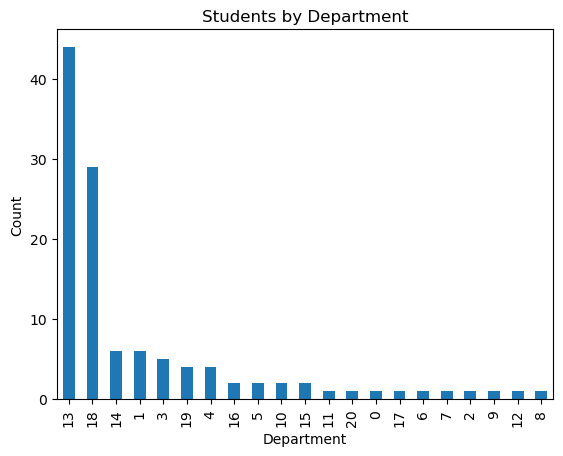

In [688]:
df["dept"].value_counts().plot(kind="bar")

plt.title("Students by Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

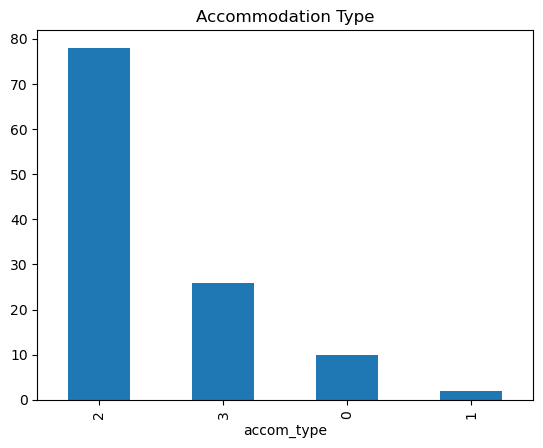

In [689]:
df["accom_type"].value_counts().plot(kind="bar")

plt.title("Accommodation Type")
plt.show()

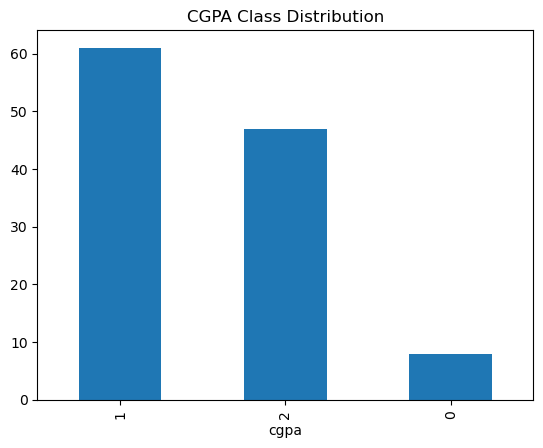

In [690]:
df["cgpa"].value_counts().plot(kind="bar")

plt.title("CGPA Class Distribution")
plt.show()

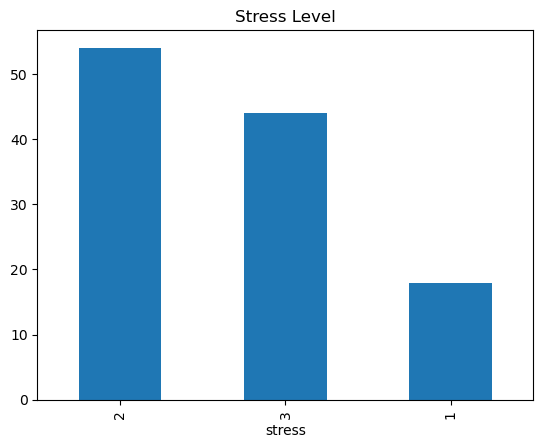

In [691]:
df["stress"].value_counts().plot(kind="bar")

plt.title("Stress Level")
plt.show()

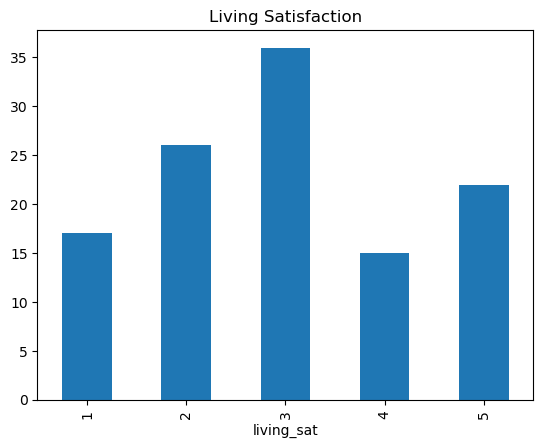

In [692]:
df["living_sat"].value_counts().sort_index().plot(kind="bar")

plt.title("Living Satisfaction")
plt.show()

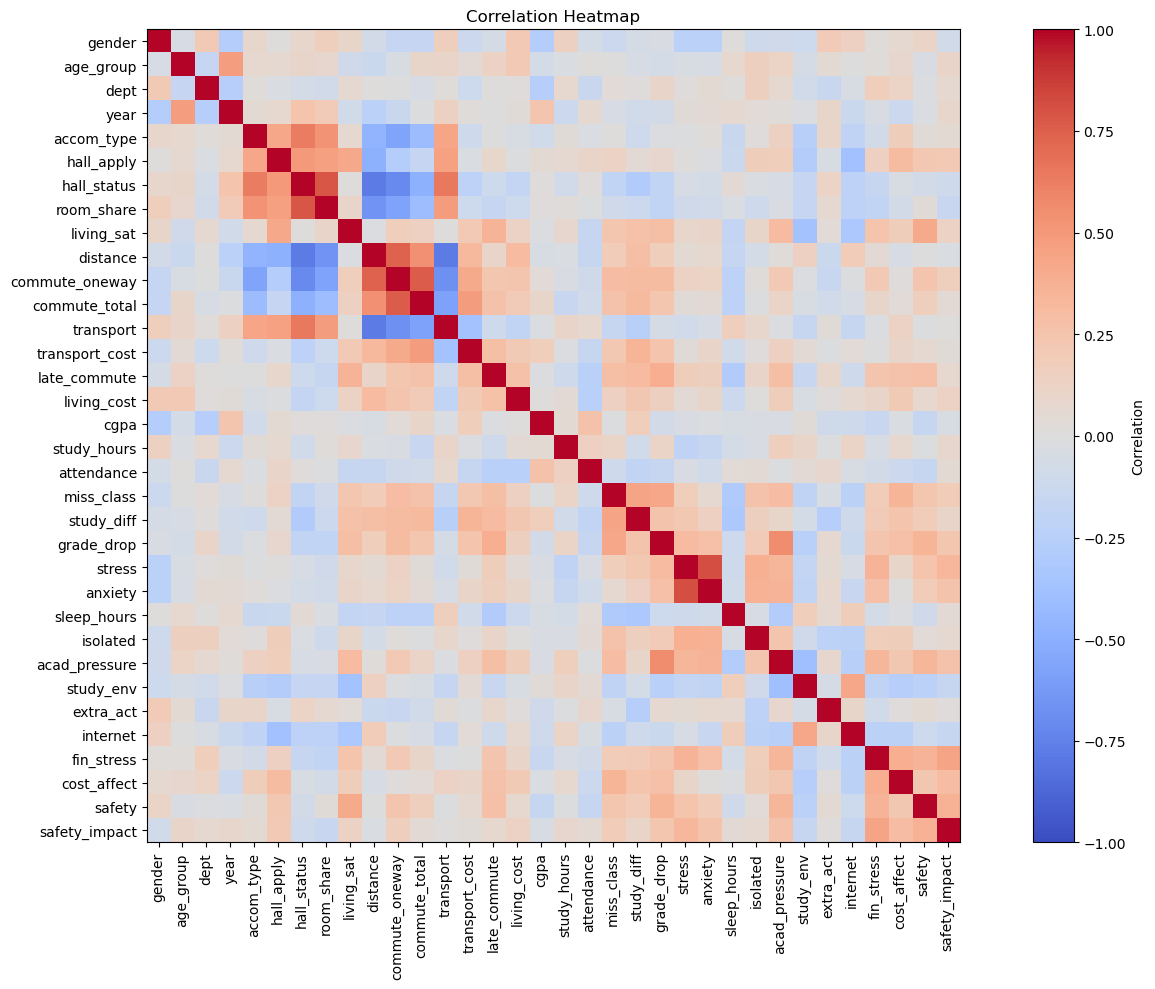

In [693]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,10))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [694]:
corr = df.corr(numeric_only=True)

print(corr["cgpa"].sort_values(ascending=False))

cgpa              1.000000
attendance        0.263953
year              0.235756
study_diff        0.166636
transport_cost    0.166034
commute_total     0.100136
hall_apply        0.052443
study_hours       0.049161
commute_oneway    0.031524
study_env         0.023542
hall_status       0.014015
room_share        0.008510
living_cost       0.007654
miss_class       -0.014117
late_commute     -0.017827
living_sat       -0.018316
anxiety          -0.021870
transport        -0.024667
cost_affect      -0.026964
acad_pressure    -0.033659
isolated         -0.034259
stress           -0.035899
safety_impact    -0.041819
distance         -0.044186
sleep_hours      -0.045447
age_group        -0.067262
grade_drop       -0.071619
accom_type       -0.081492
extra_act        -0.096366
internet         -0.101844
fin_stress       -0.144780
safety           -0.151159
dept             -0.264205
gender           -0.272875
Name: cgpa, dtype: float64


In [695]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [696]:
rf_pred = rf.predict(X_test)
rf_pred

array([1, 1, 0, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1,
       2, 2])

In [697]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [698]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [699]:
xgb_pred = xgb.predict(X_test)
xgb_pred

array([2, 2, 0, 1, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 1,
       2, 2])

In [700]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [701]:
dt_pred = dt.predict(X_test)
dt_pred

array([2, 1, 0, 2, 1, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 1, 2,
       2, 2])

In [702]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[-0.98049804, -1.00010675, -0.19611257,  0.74341721, -0.1129529 ,
         0.8304548 , -0.54992885, -1.52903586, -1.06366824, -0.35684241,
        -0.7762124 , -0.8201408 ,  0.88592074,  0.45823374, -0.0301306 ,
         0.42124716, -0.86941305,  1.22683918,  1.03461226,  0.68556546,
         1.03461226,  1.19130298,  1.16230367,  0.61419578,  1.43614066,
         0.8660254 ,  1.09271673,  0.58091139,  0.30155383,  1.6614319 ,
         0.67486706,  0.54574985,  2.22106272],
       [-0.98049804,  0.94283192,  1.05730255,  0.74341721, -0.1129529 ,
        -1.20415946, -0.54992885, -1.52903586, -1.96228452,  0.32742544,
        -0.06749673, -0.13513684, -0.72186134, -0.88897346, -0.0301306 ,
        -0.86882226, -0.86941305,  1.22683918, -0.96654567, -1.45864991,
        -0.96654567, -0.14550265, -0.16218191,  0.61419578,  0.15666989,
        -1.15470054,  1.09271673,  0.58091139,  0.30155383,  0.73279886,
        -1.48177332, -1.48526857, -1.32780924],
       [ 0.96724807,  0.9428

In [703]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [704]:
lr_pred = lr.predict(X_test)
lr_pred

array([1, 0, 0, 2, 2, 2, 1, 2, 1, 2, 2, 0, 1, 2, 2, 1, 2, 2, 2, 1, 2, 1,
       0, 2])

In [705]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    random_state=42
)

svm.fit(X_train, y_train)

SVC(random_state=42)

In [706]:
svm_pred = svm.predict(X_test)
svm_pred

array([1, 0, 0, 1, 1, 1, 0, 2, 0, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2,
       0, 2])

In [707]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [708]:
knn_pred = knn.predict(X_test)
knn_pred

array([1, 1, 0, 2, 2, 2, 1, 2, 1, 2, 2, 2, 1, 1, 1, 1, 2, 2, 1, 2, 2, 2,
       0, 2])

In [709]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model_name, y_test, y_pred):
    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print()

    print("Classification Report")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print()

In [710]:
evaluate_model("Random Forest", y_test, rf_pred)

evaluate_model("XGBoost", y_test, xgb_pred)

evaluate_model("Decision Tree", y_test, dt_pred)

evaluate_model("Logistic Regression", y_test, lr_pred)

evaluate_model("SVM", y_test, svm_pred)

evaluate_model("KNN", y_test, knn_pred)

Random Forest
Accuracy: 0.4583333333333333

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.54      0.58      0.56        12
           2       0.40      0.40      0.40        10

    accuracy                           0.46        24
   macro avg       0.31      0.33      0.32        24
weighted avg       0.44      0.46      0.45        24

Confusion Matrix
[[0 0 2]
 [1 7 4]
 [0 6 4]]

XGBoost
Accuracy: 0.4583333333333333

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.56      0.42      0.48        12
           2       0.43      0.60      0.50        10

    accuracy                           0.46        24
   macro avg       0.33      0.34      0.33        24
weighted avg       0.46      0.46      0.45        24

Confusion Matrix
[[0 0 2]
 [1 5 6]
 [0 4 6]]

Decision Tree
Accura

In [711]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print(scores)
print(scores.mean())

[0.625      0.56521739 0.43478261 0.65217391 0.69565217]
0.5945652173913043


In [712]:
from sklearn.metrics import accuracy_score

results = {
    "Random Forest": accuracy_score(y_test, rf_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "KNN": accuracy_score(y_test, knn_pred)
}

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Random Forest: 0.4583
XGBoost: 0.4583
Decision Tree: 0.6667
Logistic Regression: 0.5000
SVM: 0.4583
KNN: 0.5833


In [713]:
best_model = max(results, key=results.get)

print("Best Model:", best_model)
print("Accuracy:", results[best_model])

Best Model: Decision Tree
Accuracy: 0.6666666666666666


In [714]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

           Feature  Importance
3             year    0.086853
2             dept    0.077240
17      attendance    0.059101
1        age_group    0.054317
28        internet    0.052200
23     sleep_hours    0.048017
31          safety    0.047652
8       living_sat    0.043700
27       extra_act    0.043021
32   safety_impact    0.036084
7       room_share    0.030138
0           gender    0.029436
22         anxiety    0.028163
11   commute_total    0.026803
24        isolated    0.026081
21          stress    0.025574
29      fin_stress    0.025388
15     living_cost    0.022998
13  transport_cost    0.022892
9         distance    0.022083
26       study_env    0.022072
10  commute_oneway    0.019387
12       transport    0.019050
14    late_commute    0.018775
16     study_hours    0.017523
19      study_diff    0.016958
20      grade_drop    0.015539
4       accom_type    0.015136
30     cost_affect    0.014103
6      hall_status    0.011989
18      miss_class    0.007423
5       

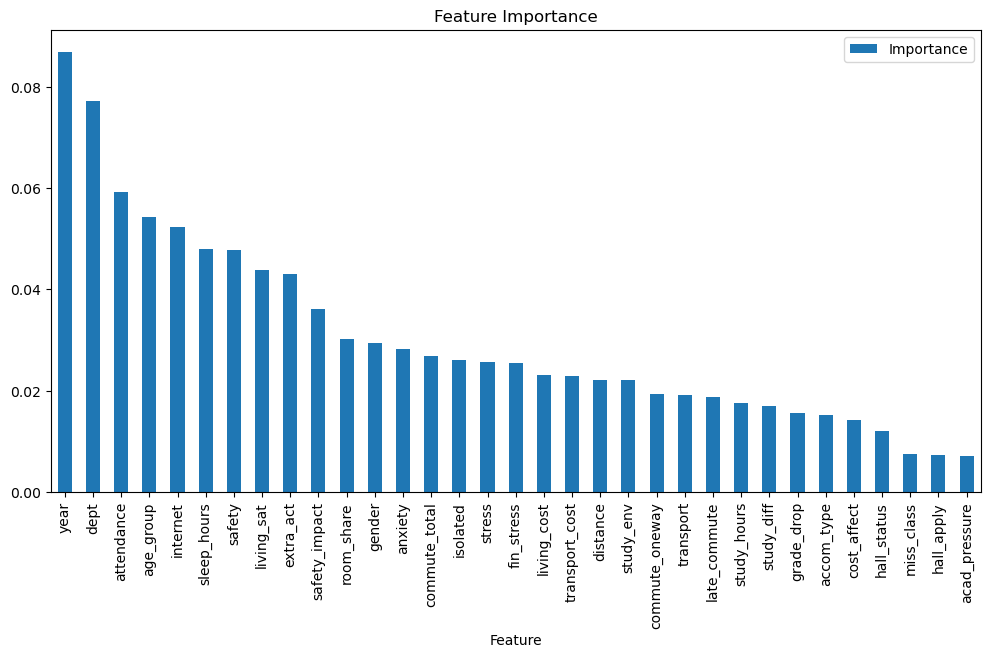

In [715]:
importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(12,6)
)

plt.title("Feature Importance")
plt.show()

Feature & Target (Living Satisfaction)

In [716]:
X = df.drop(["living_sat","stress","anxiety","isolated","study_env","acad_pressure"], axis=1)
y = df["living_sat"]

In [717]:
print(y.value_counts())

living_sat
3    36
2    26
5    22
1    17
4    15
Name: count, dtype: int64


In [718]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [719]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [720]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [721]:

pred_rf = rf.predict(X_test)
pred_rf

array([3, 3, 5, 3, 2, 5, 5, 2, 1, 3, 3, 5, 2, 3, 3, 3, 2, 3, 3, 2, 5, 3,
       2, 3])

In [722]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [723]:
pred_dt = dt.predict(X_test)
pred_dt

array([2, 3, 5, 5, 3, 5, 3, 4, 1, 3, 3, 3, 5, 4, 4, 4, 3, 5, 3, 2, 3, 4,
       4, 5])

In [724]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

SVC()

In [725]:
pred_svm = svm.predict(X_test)
pred_svm

array([3, 3, 3, 3, 1, 3, 5, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 2, 5, 3,
       2, 3])

In [726]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [727]:
pred_knn = knn.predict(X_test)
pred_knn

array([3, 2, 4, 3, 2, 4, 5, 2, 2, 3, 2, 4, 2, 4, 3, 3, 2, 2, 2, 2, 5, 3,
       2, 2])

In [728]:
evaluate_model("Random Forest", y_test, pred_rf)
evaluate_model("Decision Tree", y_test, pred_dt)
evaluate_model("SVM", y_test, pred_svm)
evaluate_model("KNN", y_test, pred_knn)

Random Forest
Accuracy: 0.3333333333333333

Classification Report
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         5
           3       0.42      0.71      0.53         7
           4       0.00      0.00      0.00         3
           5       0.60      0.60      0.60         5

    accuracy                           0.33        24
   macro avg       0.20      0.26      0.23        24
weighted avg       0.25      0.33      0.28        24

Confusion Matrix
[[0 4 0 0 0]
 [0 0 5 0 0]
 [0 1 5 0 1]
 [0 1 1 0 1]
 [1 0 1 0 3]]

Decision Tree
Accuracy: 0.20833333333333334

Classification Report
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         5
           3       0.33      0.43      0.38         7
           4       0.17      0.33      0.22         3
           5       0.17

d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: Undefine

In [729]:
from sklearn.metrics import accuracy_score

results = {
    "Random Forest": accuracy_score(y_test, pred_rf),
    "Decision Tree": accuracy_score(y_test, pred_dt),
    "SVM": accuracy_score(y_test, pred_svm),
    "KNN": accuracy_score(y_test, pred_knn)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Random Forest: 0.3333
Decision Tree: 0.2083
SVM: 0.4167
KNN: 0.2500


In [730]:
best_model = max(results, key=results.get)

print("Best Model:", best_model)
print("Accuracy:", results[best_model])

Best Model: SVM
Accuracy: 0.4166666666666667


Replacing the satisfaction level with three class

In [731]:
df["living_sat"] = df["living_sat"].replace({
    1: 0,
    2: 0,
    3: 1,
    4: 2,
    5: 2
})

In [732]:
print(df["living_sat"].value_counts())

living_sat
0    43
2    37
1    36
Name: count, dtype: int64


In [733]:
X = df.drop(
    ["living_sat", "cgpa", "stress", "anxiety", "isolated", "study_env", "acad_pressure"],
    axis=1
)

y = df["living_sat"]

In [734]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [735]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [736]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

evaluate_model("Logistic Regression", y_test, y_pred_lr)

Logistic Regression
Accuracy: 0.5833333333333334

Classification Report
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         9
           1       0.50      0.43      0.46         7
           2       0.56      0.62      0.59         8

    accuracy                           0.58        24
   macro avg       0.57      0.57      0.57        24
weighted avg       0.58      0.58      0.58        24

Confusion Matrix
[[6 1 2]
 [2 3 2]
 [1 2 5]]



In [737]:
from sklearn.svm import SVC

svm = SVC(random_state=42)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

evaluate_model("SVM", y_test, y_pred_svm)

SVM
Accuracy: 0.5833333333333334

Classification Report


              precision    recall  f1-score   support

           0       0.70      0.78      0.74         9
           1       0.33      0.29      0.31         7
           2       0.62      0.62      0.62         8

    accuracy                           0.58        24
   macro avg       0.55      0.56      0.56        24
weighted avg       0.57      0.58      0.57        24

Confusion Matrix
[[7 2 0]
 [2 2 3]
 [1 2 5]]



In [738]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

evaluate_model("KNN", y_test, y_pred_knn)

KNN
Accuracy: 0.5416666666666666

Classification Report
              precision    recall  f1-score   support

           0       0.58      0.78      0.67         9
           1       0.33      0.29      0.31         7
           2       0.67      0.50      0.57         8

    accuracy                           0.54        24
   macro avg       0.53      0.52      0.52        24
weighted avg       0.54      0.54      0.53        24

Confusion Matrix
[[7 2 0]
 [3 2 2]
 [2 2 4]]



In [739]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

evaluate_model("Random Forest", y_test, y_pred_rf)

Random Forest
Accuracy: 0.5

Classification Report
              precision    recall  f1-score   support

           0       0.60      0.67      0.63         9
           1       0.33      0.29      0.31         7
           2       0.50      0.50      0.50         8

    accuracy                           0.50        24
   macro avg       0.48      0.48      0.48        24
weighted avg       0.49      0.50      0.49        24

Confusion Matrix
[[6 2 1]
 [2 2 3]
 [2 2 4]]



In [740]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

evaluate_model("Decision Tree", y_test, y_pred_dt)

Decision Tree
Accuracy: 0.5

Classification Report
              precision    recall  f1-score   support

           0       0.62      0.56      0.59         9
           1       0.44      0.57      0.50         7
           2       0.43      0.38      0.40         8

    accuracy                           0.50        24
   macro avg       0.50      0.50      0.50        24
weighted avg       0.51      0.50      0.50        24

Confusion Matrix
[[5 2 2]
 [1 4 2]
 [2 3 3]]



In [741]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

evaluate_model("XGBoost", y_test, y_pred_xgb)

XGBoost
Accuracy: 0.5416666666666666

Classification Report
              precision    recall  f1-score   support

           0       0.67      0.44      0.53         9
           1       0.56      0.71      0.62         7
           2       0.44      0.50      0.47         8

    accuracy                           0.54        24
   macro avg       0.56      0.55      0.54        24
weighted avg       0.56      0.54      0.54        24

Confusion Matrix
[[4 1 4]
 [1 5 1]
 [1 3 4]]



In [742]:
results = {
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "XGBoost": accuracy_score(y_test, y_pred_xgb),
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "KNN": accuracy_score(y_test, y_pred_knn)
}

for model, accuracy in results.items():
    print(f"{model}: {accuracy:.4f}")

Random Forest: 0.5000
Decision Tree: 0.5000
XGBoost: 0.5417
Logistic Regression: 0.5833
SVM: 0.5833
KNN: 0.5417


In [743]:
best_model = max(results, key=results.get)

print("Best Model:", best_model)
print("Accuracy:", results[best_model])

Best Model: Logistic Regression
Accuracy: 0.5833333333333334


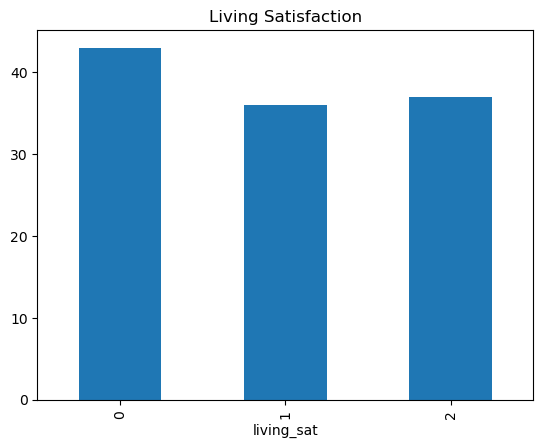

In [744]:
df["living_sat"].value_counts().sort_index().plot(kind="bar")

plt.title("Living Satisfaction")
plt.show()

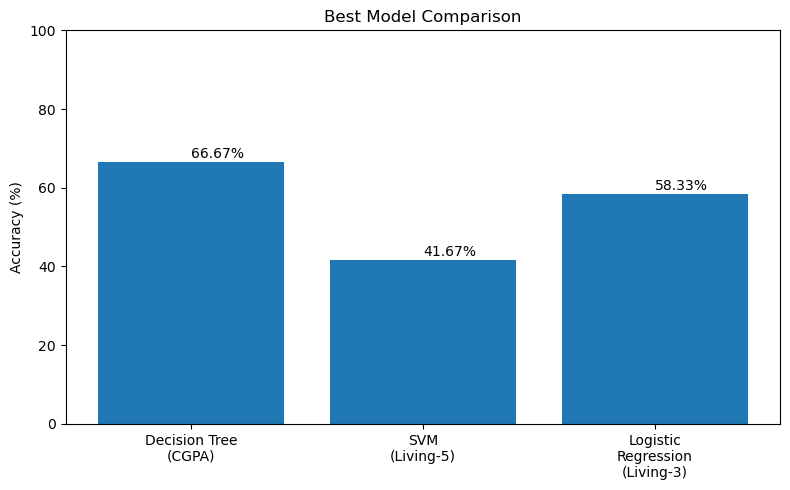

In [745]:

models = [
    "Decision Tree\n(CGPA)",
    "SVM\n(Living-5)",
    "Logistic\nRegression\n(Living-3)"
]

accuracy = [
    66.67,
    41.67,
    58.33
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")

plt.ylim(0,100)

plt.title("Best Model Comparison")

for i,v in enumerate(accuracy):
    plt.text(i,v+1,f"{v:.2f}%")

plt.tight_layout()

plt.savefig("model_comparison.png",dpi=300)

plt.show()

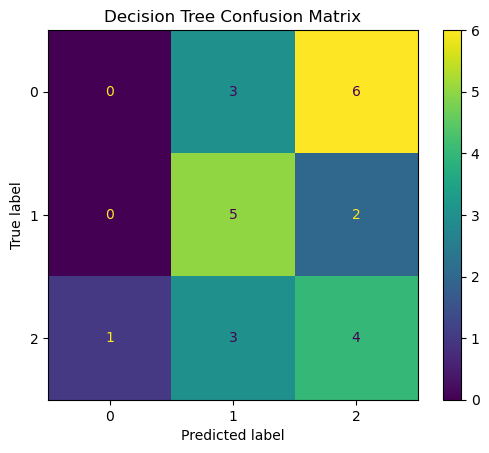

In [746]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Decision Tree Confusion Matrix")

plt.savefig("confusion_matrix.png",dpi=300)

plt.show()